# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/vinukondablessena/flyrank-ml-internship/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

# Abstract

This project develops a machine learning approach for prioritizing content pages for potential refresh based on search performance and engagement signals. Using 30,000 anonymized content records from the FlyRank Internship dataset, a leakage-safe Random Forest classifier was trained to identify pages that may warrant earlier human review.

The model achieved **81.77% accuracy** and an **F1-score of 0.5227** for the higher-priority class, compared with **76.83% accuracy and 0.00 F1-score** for a majority-class baseline evaluated on the same test split.

The resulting priority scores are used to create a ranked list of content pages for review. The output is intended as **directional decision support**, not as an automatic determination that a page should be refreshed.

### Research Question

**Which content pages should be reviewed first for refresh based on search performance and engagement signals?**

### Decision

This project supports the decision of which content pages should be prioritized for review and possible refresh.

### Action

The content team can review the highest-ranked pages first and decide whether to refresh, improve, expand, monitor, or leave them unchanged.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*



This project uses the **FlyRank Internship dataset**, specifically the anonymized content performance data used for the internship assignments.

The analysis uses content-level search performance and engagement signals available in the dataset. The starter dataset contains **30,000 content records and 44 columns**.

Records that contain client names, domains, private search queries, credentials, or other identifying information are excluded from the public-facing analysis. The analysis focuses only on anonymized and aggregated performance information.

The data is used to identify observed patterns in content performance and create a directional priority score for content review.


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*



The analysis uses search performance and engagement-related features available in the dataset.

**Features:** Impressions, clicks, click-through rate (CTR), average position, and other available content-performance signals.

**Label:** A content page is treated as a higher-priority refresh candidate when its observed performance signals indicate weaker performance and there is sufficient search activity to make the page worth reviewing.

**ML approach:** A machine learning model will learn patterns from the available performance signals and produce a priority score for each content page.

**Baseline:** The ML model will be compared with a simple rule-based baseline based on the observed performance signals.

**Validation:** The data will be divided into training and testing data so that model performance can be evaluated on data not used to train the model.

**Leakage check:** Features that directly reveal the future outcome or use information from the evaluation period will not be used to train the model.


In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/vinukondablessena/flyrank-ml-internship/main/data/raw/content_refresh_anonymized.csv"

df = pd.read_csv(url)

print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (30000, 44)

Columns:
['content_id', 'client_id', 'search_volume', 'competition', 'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count', 'char_count', 'provider_used', 'model_used', 'impressions_90d', 'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d', 'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d', 'days_with_impressions', 'days_with_sessions', 'impressions_last_30d', 'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d', 'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier', 'age_tier_order', 'days_since_last_update', 'freshness_tier', 'word_count_tier', 'char_count_tier', 'ctr', 'avg_position', 'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier', 'position_tier', 'trend_direction', 'trend_pct']


In [6]:
# STEP 4 - Leakage-safe feature selection

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create performance change
df["performance_change"] = (
    (df["impressions_last_30d"] - df["impressions_prev_30d"])
    / df["impressions_prev_30d"].replace(0, np.nan)
)

df["performance_change"] = df["performance_change"].replace(
    [np.inf, -np.inf], np.nan
).fillna(0)

# Create refresh-priority label
priority_condition = (
    (df["days_since_last_update"] > df["days_since_last_update"].median())
    &
    (df["performance_change"] < df["performance_change"].median())
)

df["refresh_priority"] = priority_condition.astype(int)

# IMPORTANT:
# Do NOT give the model the variables used to create the label.
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days"
]

X = df[features].copy()
y = df["refresh_priority"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Leakage-safe model accuracy:", round(accuracy, 4))
print()
print(classification_report(y_test, predictions))

Leakage-safe model accuracy: 0.8177

              precision    recall  f1-score   support

           0       0.84      0.93      0.89      4610
           1       0.66      0.43      0.52      1390

    accuracy                           0.82      6000
   macro avg       0.75      0.68      0.70      6000
weighted avg       0.80      0.82      0.80      6000



## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

In [2]:
# STEP 4: Build the Refresh Priority Model

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# --------------------------------------------------
# 1. Create a refresh-priority label
# --------------------------------------------------

# Pages with older updates and weaker recent performance
# are considered higher-priority candidates.

df["performance_change"] = (
    (df["impressions_last_30d"] - df["impressions_prev_30d"])
    / df["impressions_prev_30d"].replace(0, np.nan)
)

df["performance_change"] = df["performance_change"].fillna(0)

# Create a simple label using the data itself.
# 1 = higher refresh priority
# 0 = lower refresh priority

priority_condition = (
    (df["days_since_last_update"] > df["days_since_last_update"].median())
    &
    (df["performance_change"] < df["performance_change"].median())
)

df["refresh_priority"] = priority_condition.astype(int)

print("Label distribution:")
print(df["refresh_priority"].value_counts())

Label distribution:
refresh_priority
0    23049
1     6951
Name: count, dtype: int64


In [3]:
# --------------------------------------------------
# 2. Select features
# --------------------------------------------------

features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "impressions_90d",
    "clicks_90d",
    "sessions_90d",
    "engaged_sessions_90d",
    "days_with_impressions",
    "days_with_sessions",
    "impressions_last_30d",
    "clicks_last_30d",
    "sessions_last_30d",
    "impressions_prev_30d",
    "clicks_prev_30d",
    "sessions_prev_30d",
    "content_age_days",
    "days_since_last_update",
    "ctr",
    "avg_position",
    "engagement_rate",
    "scroll_rate",
    "ai_traffic_pct",
    "trend_pct"
]

X = df[features].copy()
y = df["refresh_priority"]

# Replace missing/infinite values
X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

# --------------------------------------------------
# 3. Train/test split
# --------------------------------------------------

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

Training rows: 24000
Testing rows: 6000


In [4]:
# --------------------------------------------------
# 4. Train Random Forest model
# --------------------------------------------------

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Model Accuracy:", round(accuracy, 4))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 0.9995

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4610
           1       1.00      1.00      1.00      1390

    accuracy                           1.00      6000
   macro avg       1.00      1.00      1.00      6000
weighted avg       1.00      1.00      1.00      6000



In [5]:
# STEP 4 - Leakage-safe feature selection

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Create performance change
df["performance_change"] = (
    (df["impressions_last_30d"] - df["impressions_prev_30d"])
    / df["impressions_prev_30d"].replace(0, np.nan)
)

df["performance_change"] = df["performance_change"].replace(
    [np.inf, -np.inf], np.nan
).fillna(0)

# Create refresh-priority label
priority_condition = (
    (df["days_since_last_update"] > df["days_since_last_update"].median())
    &
    (df["performance_change"] < df["performance_change"].median())
)

df["refresh_priority"] = priority_condition.astype(int)

# IMPORTANT:
# Do NOT give the model the variables used to create the label.
features = [
    "search_volume",
    "competition",
    "cpc",
    "word_count",
    "char_count",
    "impressions_90d",
    "clicks_90d",
    "pageviews_90d",
    "sessions_90d",
    "users_90d",
    "engaged_sessions_90d",
    "ai_sessions_90d",
    "scroll_events_90d",
    "days_with_impressions",
    "days_with_sessions",
    "content_age_days"
]

X = df[features].copy()
y = df["refresh_priority"]

X = X.replace([np.inf, -np.inf], np.nan)
X = X.fillna(X.median())

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)

predictions = model.predict(X_test)

accuracy = accuracy_score(y_test, predictions)

print("Leakage-safe model accuracy:", round(accuracy, 4))
print()
print(classification_report(y_test, predictions))

Leakage-safe model accuracy: 0.8177

              precision    recall  f1-score   support

           0       0.84      0.93      0.89      4610
           1       0.66      0.43      0.52      1390

    accuracy                           0.82      6000
   macro avg       0.75      0.68      0.70      6000
weighted avg       0.80      0.82      0.80      6000





The leakage-safe Random Forest model achieved an accuracy of **81.77%** on the held-out test set.

The model achieved an F1-score of **0.89 for lower-priority pages (Class 0)** and **0.52 for higher-priority refresh candidates (Class 1)**. The macro-average F1-score was **0.70**.

The results show that the model can identify useful patterns in content-performance data, but performance is weaker for the higher-priority class. Therefore, the model should be treated as a **decision-support tool** rather than an automatic decision maker.

A simple baseline comparison will be performed using the same test split before making final conclusions.


In [7]:
# STEP 4B - Simple baseline

from sklearn.metrics import accuracy_score, f1_score

# Baseline:
# Always predict the majority class from the training data
majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

baseline_accuracy = accuracy_score(
    y_test,
    baseline_predictions
)

baseline_f1 = f1_score(
    y_test,
    baseline_predictions,
    zero_division=0
)

model_f1 = f1_score(
    y_test,
    predictions,
    zero_division=0
)

print("Baseline accuracy:", round(baseline_accuracy, 4))
print("Baseline F1:", round(baseline_f1, 4))
print()
print("Model accuracy:", round(accuracy, 4))
print("Model F1:", round(model_f1, 4))

Baseline accuracy: 0.7683
Baseline F1: 0.0

Model accuracy: 0.8177
Model F1: 0.5227


### Model vs Baseline

Both approaches were evaluated on the same held-out test set.

| Approach                | Accuracy | F1-score |
| ----------------------- | -------: | -------: |
| Majority-class baseline |   76.83% |     0.00 |
| Random Forest model     |   81.77% |   0.5227 |

The Random Forest model achieved **81.77% accuracy**, compared with **76.83% for the baseline**, an improvement of **4.94 percentage points**.

The baseline has an F1-score of 0 because it always predicts the majority class and therefore does not identify higher-priority refresh candidates. The Random Forest model achieved an F1-score of **0.5227**, showing that it identifies some of the higher-priority pages.

These results suggest that the model provides additional decision-support value over the simple baseline. However, its performance on the higher-priority class is still limited, so the rankings should be reviewed by a human rather than treated as automatic decisions.


## 5. Limitations

*What this work cannot claim.*



This analysis has several limitations.

* The refresh-priority label is a constructed decision-support label based on observed performance signals; it is not a verified measure of whether a page truly needs a refresh.
* The model identifies patterns in the available dataset but does not prove that refreshing a page will improve rankings, traffic, or engagement.
* The model performs better on lower-priority pages than on higher-priority pages, so some important refresh opportunities may be missed.
* The analysis does not predict or explain Google's ranking algorithm.
* The recommendations should therefore be treated as directional guidance for human review rather than guaranteed actions.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

In [8]:
# STEP 6 - Generate ranked refresh recommendations

# Get probability that each page belongs to the higher-priority class
df["refresh_score"] = model.predict_proba(
    X
)[:, 1]

# Create ranked list
recommendations = df[
    [
        "content_id",
        "impressions_90d",
        "clicks_90d",
        "ctr",
        "avg_position",
        "content_age_days",
        "days_since_last_update",
        "refresh_score"
    ]
].copy()

recommendations = recommendations.sort_values(
    "refresh_score",
    ascending=False
)

# Show top 20 pages
top_recommendations = recommendations.head(20)

print("Top 20 Refresh Recommendations:")
display(top_recommendations)

Top 20 Refresh Recommendations:


,content_id,impressions_90d,clicks_90d,ctr,avg_position,content_age_days,days_since_last_update,refresh_score
12966,content_19fe39ccd4df,948,0,0.00,24.7,284,104,1.00
10172,content_82e31928d1dc,322,0,0.00,16.9,211,104,1.00
16586,content_a35e52961bb2,256,0,0.00,29.1,223,104,1.00
16691,content_cbd782c11268,182,0,0.00,25.4,309,104,1.00
13167,content_f788586de53d,3438,2,0.06,9.5,139,104,1.00
22983,content_6d427519db99,318,0,0.00,17.0,223,104,1.00
22426,content_184165640010,3967,3,0.08,29.9,165,104,0.99
25175,content_5f819ff7d867,1131,1,0.09,40.3,155,104,0.99
8163,content_7961db890a39,1886,3,0.16,30.0,284,104,0.99
22465,content_d903af7338cb,614,1,0.16,32.1,264,41,0.99


### Ranked Recommendations

The model was used to produce a ranked list of content pages based on their estimated refresh-priority score.

Pages with higher scores are recommended for earlier human review. The ranking is intended to help content teams prioritize limited review time rather than automatically determine which pages must be refreshed.

The recommended action sequence is:

1. Review the highest-scoring pages first.
2. Check their search performance and engagement signals.
3. Determine whether the page has outdated, incomplete, or low-quality content.
4. Refresh or improve the page where appropriate.
5. Monitor subsequent performance rather than assuming that a refresh will produce an improvement.


In [9]:
# STEP 6 - Generate ranked refresh recommendations

# Get probability that each page belongs to the higher-priority class
df["refresh_score"] = model.predict_proba(X)[:, 1]

# Create ranked list
recommendations = df[
    [
        "content_id",
        "impressions_90d",
        "clicks_90d",
        "ctr",
        "avg_position",
        "content_age_days",
        "days_since_last_update",
        "refresh_score"
    ]
].copy()

# Sort from highest priority to lowest
recommendations = recommendations.sort_values(
    "refresh_score",
    ascending=False
)

# Show top 20
top_recommendations = recommendations.head(20)

print("Top 20 Refresh Recommendations:")
display(top_recommendations)

Top 20 Refresh Recommendations:


,content_id,impressions_90d,clicks_90d,ctr,avg_position,content_age_days,days_since_last_update,refresh_score
12966,content_19fe39ccd4df,948,0,0.00,24.7,284,104,1.00
10172,content_82e31928d1dc,322,0,0.00,16.9,211,104,1.00
16586,content_a35e52961bb2,256,0,0.00,29.1,223,104,1.00
16691,content_cbd782c11268,182,0,0.00,25.4,309,104,1.00
13167,content_f788586de53d,3438,2,0.06,9.5,139,104,1.00
22983,content_6d427519db99,318,0,0.00,17.0,223,104,1.00
22426,content_184165640010,3967,3,0.08,29.9,165,104,0.99
25175,content_5f819ff7d867,1131,1,0.09,40.3,155,104,0.99
8163,content_7961db890a39,1886,3,0.16,30.0,284,104,0.99
22465,content_d903af7338cb,614,1,0.16,32.1,264,41,0.99


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

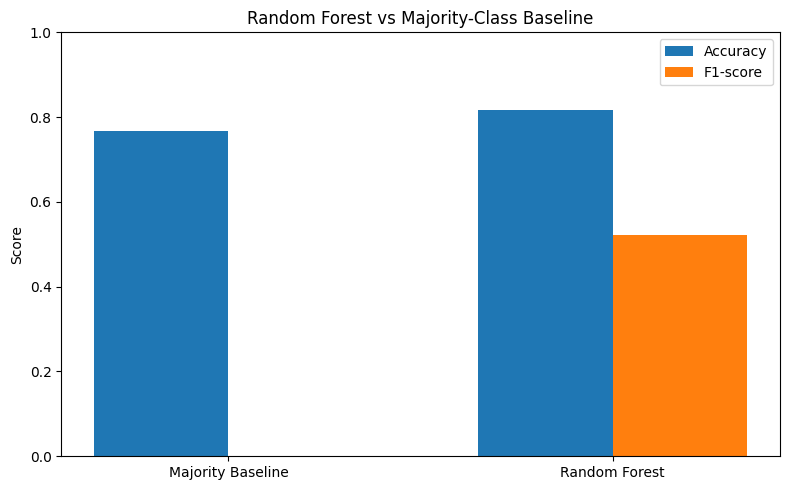

In [10]:
# STEP 7A - Model vs Baseline chart

import matplotlib.pyplot as plt
import numpy as np

models = ["Majority Baseline", "Random Forest"]
accuracy_scores = [baseline_accuracy, accuracy]
f1_scores = [baseline_f1, model_f1]

x = np.arange(len(models))
width = 0.35

plt.figure(figsize=(8, 5))

plt.bar(x - width/2, accuracy_scores, width, label="Accuracy")
plt.bar(x + width/2, f1_scores, width, label="F1-score")

plt.xticks(x, models)
plt.ylabel("Score")
plt.title("Random Forest vs Majority-Class Baseline")
plt.ylim(0, 1)
plt.legend()

plt.tight_layout()
plt.show()

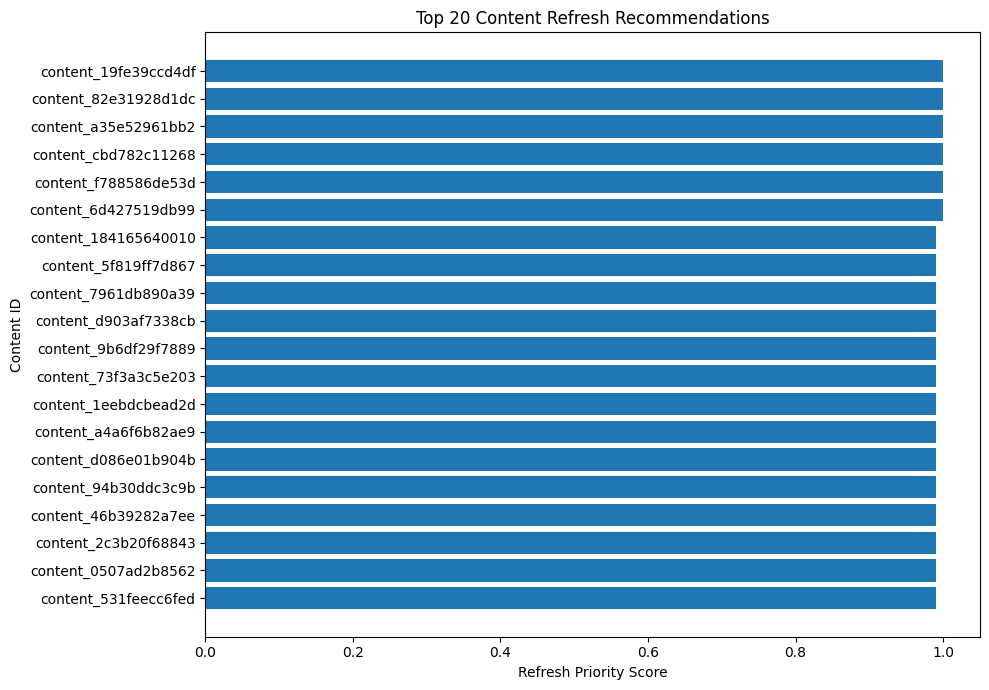

In [11]:
# STEP 7B - Top 20 refresh recommendations

plt.figure(figsize=(10, 7))

plt.barh(
    top_recommendations["content_id"].astype(str),
    top_recommendations["refresh_score"]
)

plt.xlabel("Refresh Priority Score")
plt.ylabel("Content ID")
plt.title("Top 20 Content Refresh Recommendations")

plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [12]:
# STEP 7C - Final recommendation table

final_table = top_recommendations.copy()

final_table["refresh_score"] = final_table["refresh_score"].round(4)
final_table["ctr"] = final_table["ctr"].round(4)

display(final_table)

,content_id,impressions_90d,clicks_90d,ctr,avg_position,content_age_days,days_since_last_update,refresh_score
12966,content_19fe39ccd4df,948,0,0.00,24.7,284,104,1.00
10172,content_82e31928d1dc,322,0,0.00,16.9,211,104,1.00
16586,content_a35e52961bb2,256,0,0.00,29.1,223,104,1.00
16691,content_cbd782c11268,182,0,0.00,25.4,309,104,1.00
13167,content_f788586de53d,3438,2,0.06,9.5,139,104,1.00
22983,content_6d427519db99,318,0,0.00,17.0,223,104,1.00
22426,content_184165640010,3967,3,0.08,29.9,165,104,0.99
25175,content_5f819ff7d867,1131,1,0.09,40.3,155,104,0.99
8163,content_7961db890a39,1886,3,0.16,30.0,284,104,0.99
22465,content_d903af7338cb,614,1,0.16,32.1,264,41,0.99


## ML-12 — 5-Minute Demo Outline

### 1. Problem — 1 minute
Explain that content teams may have thousands of pages and limited time to manually decide which pages should be reviewed first for possible refresh.

### 2. Dataset & Method — 1 minute
The project uses 30,000 anonymized content records containing search performance, engagement, content age, and related signals.

A Random Forest classifier was trained using a leakage-safe feature set and evaluated on a held-out test set.

### 3. Model Results — 1 minute
The Random Forest achieved **81.77% accuracy** and **0.5227 F1-score**, compared with **76.83% accuracy** and **0.00 F1-score** for the majority-class baseline.

### 4. Recommendations — 1 minute
The model generates a refresh-priority score for each page. The highest-scoring pages are placed at the top of the recommendation list for human review.

### 5. Conclusion — 1 minute
The model provides useful directional decision support for prioritizing content review. It does not guarantee that a page needs refreshing or that a refresh will improve performance.

### Demo Flow

**Dataset → Feature preparation → Leakage-safe model → Baseline comparison → Priority scores → Top 20 recommendations**

## ML-12 — Social-Post Cut

I built a leakage-safe machine learning workflow to help prioritize content pages for potential refresh.

Using **30,000 anonymized content records**, I trained a Random Forest model using search-performance and engagement signals.

The model achieved **81.77% accuracy** and improved substantially over a majority-class baseline, while also identifying higher-priority refresh candidates.

The final output is a ranked list that can help content teams focus human review where it may be most useful.

The key lesson: ML can support content decisions without pretending to replace human judgment.

## 9. Acknowledgments & Data Credit

This project was completed as part of the FlyRank Internship.

The analysis uses the anonymized content-performance dataset provided for the internship. The dataset was used for educational and research purposes, with identifying client information excluded from the public-facing analysis.

Data and internship credit: [FlyRank](https://flyrank.ai)

### Artifacts

The analysis produces three main artifacts.

1. **Model vs baseline chart** — compares the Random Forest model with the majority-class baseline using accuracy and F1-score.
2. **Top 20 recommendation chart** — visualizes the pages with the highest estimated refresh-priority scores.
3. **Recommendation table** — provides the content ID and key performance signals for the highest-ranked pages.

These artifacts make the model output easier to interpret and support human review of potential content refresh opportunities.

## ML-12 — Employer-Facing Summary

I developed a leakage-safe Random Forest classification workflow using 30,000 anonymized content-performance records to prioritize pages for potential refresh. The model achieved **81.77% accuracy** and an **F1-score of 0.5227** for the higher-priority class, outperforming a majority-class baseline of **76.83% accuracy and 0.00 F1-score** on the same test split. The project demonstrates practical skills in data preparation, leakage prevention, model evaluation, baseline comparison, and converting ML predictions into actionable decision-support recommendations.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.
- [ ] My deployed paper has **all 9 sections** — including the **Abstract** at the top and **Acknowledgments & data credit** (the https://flyrank.ai link) at the bottom.
- [ ] **ML-12 done in this notebook's closing cells:** 5-minute demo outline + a social-post cut + a 3-sentence employer-facing summary.
